# **Exercise 1: Exploring Text Preprocessing usage, NER and POS tags**

# Data

In [49]:
data = {
    'Review': [
        "At McDonald's the food was ok and the service was bad.",
        "I would not recommend this Japanese restaurant to anyone.",
        "I loved this restaurant when I traveled to Thailand last summer.",
        "The menu of Loving has a wide variety of options.",
        "The staff was friendly and helpful at Google's employees restaurant.",
        "The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.",
        "I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.",
        "The sushi at Sushi Express is always fresh and flavorful.",
        "The steakhouse on Main Street has a cozy atmosphere and excellent steaks.",
        "The dessert selection at Sweet Treats is to die for!"
    ]
}

# Setup

In [50]:
import pandas as pd
import nltk
import spacy
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Downloading dependencies
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

# Loading spacy English model
nlp = spacy.load('en_core_web_sm')

# Load dataset
df = pd.DataFrame(data)
df.head()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


,Review
0,At McDonald's the food was ok and the service ...
1,I would not recommend this Japanese restaurant...
2,I loved this restaurant when I traveled to Tha...
3,The menu of Loving has a wide variety of options.
4,The staff was friendly and helpful at Google's...


# Preprocessing Function

In [51]:
def preprocess_text(text):
  # Convert to lowercase
  text = text.lower()

  # Tokenize
  tokens = word_tokenize(text)

  # Remove punctations
  stop_words = set(stopwords.words("english"))
  tokens = [word for word in tokens if word not in stop_words]

  # Lemmatize
  lemmatizer = WordNetLemmatizer()
  tokens = [lemmatizer.lemmatize(word) for word in tokens]

  return " ".join(tokens)


In [52]:
df["Cleaned"] = df["Review"].apply(preprocess_text)
print(df.columns)

Index(['Review', 'Cleaned'], dtype='object')


In [53]:
df[["Review", "Cleaned"]]

,Review,Cleaned
0,At McDonald's the food was ok and the service ...,mcdonald 's food ok service bad .
1,I would not recommend this Japanese restaurant...,would recommend japanese restaurant anyone .
2,I loved this restaurant when I traveled to Tha...,loved restaurant traveled thailand last summer .
3,The menu of Loving has a wide variety of options.,menu loving wide variety option .
4,The staff was friendly and helpful at Google's...,staff friendly helpful google 's employee rest...
5,"The ambiance at Bella Italia is amazing, and t...","ambiance bella italia amazing , pasta dish del..."
6,I had a terrible experience at Pizza Hut. The ...,"terrible experience pizza hut . pizza burnt , ..."
7,The sushi at Sushi Express is always fresh and...,sushi sushi express always fresh flavorful .
8,The steakhouse on Main Street has a cozy atmos...,steakhouse main street cozy atmosphere excelle...
9,The dessert selection at Sweet Treats is to di...,dessert selection sweet treat die !


# Named Entity Recognnition (NER)

In [54]:
def perform_ner(text):
  doc = nlp(text)
  entities = [(ent.text, ent.label_) for ent in doc.ents]
  return entities

  # Example
  df["Entities"] = df["Review"].apply(perform_ner)
  df[["Review", "Entities"]]

# POS Tagging (Parts of Speech)

In [55]:
def perform_pos_tagging(text):
  tokens = word_tokenize(text)
  tags = nltk.pos_tag(tokens)
  return tags
# Apply to raw text
df["POS_Tags"] = df["Review"].apply(perform_pos_tagging)
df[["Review", "POS_Tags"]]

,Review,POS_Tags
0,At McDonald's the food was ok and the service ...,"[(At, IN), (McDonald, NNP), ('s, POS), (the, D..."
1,I would not recommend this Japanese restaurant...,"[(I, PRP), (would, MD), (not, RB), (recommend,..."
2,I loved this restaurant when I traveled to Tha...,"[(I, PRP), (loved, VBD), (this, DT), (restaura..."
3,The menu of Loving has a wide variety of options.,"[(The, DT), (menu, NN), (of, IN), (Loving, NNP..."
4,The staff was friendly and helpful at Google's...,"[(The, DT), (staff, NN), (was, VBD), (friendly..."
5,"The ambiance at Bella Italia is amazing, and t...","[(The, DT), (ambiance, NN), (at, IN), (Bella, ..."
6,I had a terrible experience at Pizza Hut. The ...,"[(I, PRP), (had, VBD), (a, DT), (terrible, JJ)..."
7,The sushi at Sushi Express is always fresh and...,"[(The, DT), (sushi, NN), (at, IN), (Sushi, NNP..."
8,The steakhouse on Main Street has a cozy atmos...,"[(The, DT), (steakhouse, NN), (on, IN), (Main,..."
9,The dessert selection at Sweet Treats is to di...,"[(The, DT), (dessert, JJ), (selection, NN), (a..."


# **Compare Raw vs Cleaned Text**

In [63]:
df["NER_Cleaned"] = df["Cleaned"].apply(perform_ner)
df['POS_Cleaned'] = df['Cleaned'].apply(perform_pos_tagging)

# Now displaying everything safely
df[["Review", "Cleaned", "Entities", "NER_Cleaned", "POS_Tags", "POS_Cleaned"]]

,Review,Cleaned,Entities,NER_Cleaned,POS_Tags,POS_Cleaned
0,At McDonald's the food was ok and the service ...,mcdonald 's food ok service bad .,"[(McDonald, ORG)]","[(mcdonald 's food ok service, ORG)]","[(At, IN), (McDonald, NNP), ('s, POS), (the, D...","[(mcdonald, NN), ('s, POS), (food, NN), (ok, J..."
1,I would not recommend this Japanese restaurant...,would recommend japanese restaurant anyone .,"[(Japanese, NORP)]","[(japanese, NORP)]","[(I, PRP), (would, MD), (not, RB), (recommend,...","[(would, MD), (recommend, VB), (japanese, JJ),..."
2,I loved this restaurant when I traveled to Tha...,loved restaurant traveled thailand last summer .,"[(Thailand, GPE), (last summer, DATE)]","[(thailand, GPE), (last summer, DATE)]","[(I, PRP), (loved, VBD), (this, DT), (restaura...","[(loved, VBN), (restaurant, NN), (traveled, VB..."
3,The menu of Loving has a wide variety of options.,menu loving wide variety option .,"[(Loving, GPE)]",[],"[(The, DT), (menu, NN), (of, IN), (Loving, NNP...","[(menu, NN), (loving, VBG), (wide, JJ), (varie..."
4,The staff was friendly and helpful at Google's...,staff friendly helpful google 's employee rest...,"[(Google, ORG)]","[(google, ORG)]","[(The, DT), (staff, NN), (was, VBD), (friendly...","[(staff, NN), (friendly, RB), (helpful, JJ), (..."
5,"The ambiance at Bella Italia is amazing, and t...","ambiance bella italia amazing , pasta dish del...","[(Bella Italia, ORG)]","[(ambiance bella italia, PERSON)]","[(The, DT), (ambiance, NN), (at, IN), (Bella, ...","[(ambiance, NN), (bella, NN), (italia, NN), (a..."
6,I had a terrible experience at Pizza Hut. The ...,"terrible experience pizza hut . pizza burnt , ...","[(Pizza Hut, ORG)]",[],"[(I, PRP), (had, VBD), (a, DT), (terrible, JJ)...","[(terrible, JJ), (experience, NN), (pizza, NN)..."
7,The sushi at Sushi Express is always fresh and...,sushi sushi express always fresh flavorful .,"[(Sushi Express, ORG)]",[],"[(The, DT), (sushi, NN), (at, IN), (Sushi, NNP...","[(sushi, NN), (sushi, NN), (express, NN), (alw..."
8,The steakhouse on Main Street has a cozy atmos...,steakhouse main street cozy atmosphere excelle...,"[(Main Street, FAC)]",[],"[(The, DT), (steakhouse, NN), (on, IN), (Main,...","[(steakhouse, NN), (main, JJ), (street, NN), (..."
9,The dessert selection at Sweet Treats is to di...,dessert selection sweet treat die !,"[(Sweet Treats, PERSON)]",[],"[(The, DT), (dessert, JJ), (selection, NN), (a...","[(dessert, JJ), (selection, NN), (sweet, JJ), ..."


# **Exercise 2: Plotting the word embeddings**

# Building a tokennized corpus & train Word2Vec

In [70]:
!pip install gensim

In [72]:
!pip install scipy==1.10.1

ERROR: Ignored the following yanked versions: 1.11.0, 1.14.0rc1
ERROR: Ignored the following versions that require a different python version: 1.10.0 Requires-Python <3.12,>=3.8; 1.10.0rc1 Requires-Python <3.12,>=3.8; 1.10.0rc2 Requires-Python <3.12,>=3.8; 1.10.1 Requires-Python <3.12,>=3.8; 1.6.2 Requires-Python >=3.7,<3.10; 1.6.3 Requires-Python >=3.7,<3.10; 1.7.0 Requires-Python >=3.7,<3.10; 1.7.1 Requires-Python >=3.7,<3.10; 1.7.2 Requires-Python >=3.7,<3.11; 1.7.3 Requires-Python >=3.7,<3.11; 1.8.0 Requires-Python >=3.8,<3.11; 1.8.0rc1 Requires-Python >=3.8,<3.11; 1.8.0rc2 Requires-Python >=3.8,<3.11; 1.8.0rc3 Requires-Python >=3.8,<3.11; 1.8.0rc4 Requires-Python >=3.8,<3.11; 1.8.1 Requires-Python >=3.8,<3.11; 1.9.0 Requires-Python >=3.8,<3.12; 1.9.0rc1 Requires-Python >=3.8,<3.12; 1.9.0rc2 Requires-Python >=3.8,<3.12; 1.9.0rc3 Requires-Python >=3.8,<3.12; 1.9.1 Requires-Python >=3.8,<3.12
ERROR: Could not find a version that satisfies the requirement scipy==1.10.1 (from versions:

In [73]:
!pip install --upgrade gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 30.1 MB/s eta 0:00:00
  Attempting uninstall: gensim
    Found existing installation: gensim 4.3.2
    Uninstalling gensim-4.3.2:
      Successfully uninstalled gensim-4.3.2


In [74]:
import re
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from gensim.models import Word2Vec
from sklearn.decomposition import PCA

# --- A) tokenize the cleaned text into lists of tokens (sentences) ---
def simple_tokenize(s):
    # split on non-letters, keep words only
    return [w for w in re.split(r"[^a-zA-Z']+", s.lower()) if w]

corpus = [simple_tokenize(text) for text in df["Cleaned"].tolist()]
# Example: [['mcdonald', 'food', 'ok', 'service', 'bad'], ['would', 'recommend', ...], ...]

# --- B) train a small Word2Vec (tweakable) ---
w2v = Word2Vec(
    sentences=corpus,
    vector_size=100,   # embedding dimension (try 50/100/200)
    window=5,          # context window
    min_count=1,       # keep all words (small dataset)
    workers=2,         # threads
    sg=1,              # 1=skip-gram (usually better on small data), 0=CBOW
    epochs=200         # more passes to learn from tiny corpus
)

# Inspecting the embedding dimennsions

In [75]:
vector_dim = w2v.wv.vectors.shape[1]
vocab_size = len(w2v.wv)
print("Embedding vector dimesnion:", vector_dim)
print("Vocabulary size:", vocab_size)

Embedding vector dimesnion: 100
Vocabulary size: 56


# Plot word embeddings (2D) with labels

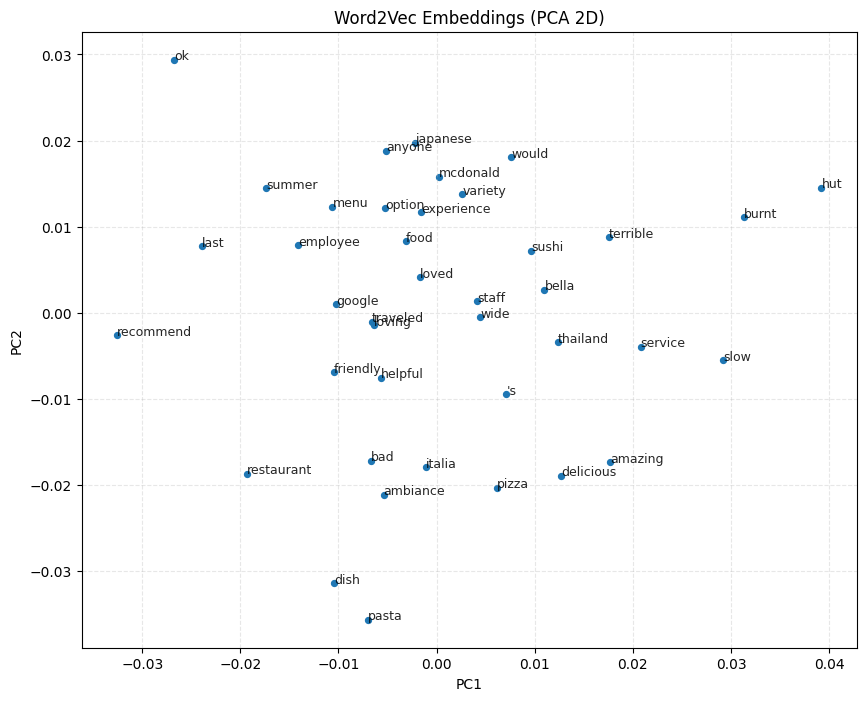

In [76]:
def plot_word_embeddings(model, top_n=50):
    """
    Plots up to top_n words from the vocabulary using PCA->2D.
    Words are annotated on the scatter.
    """
    # Pick top_n frequent words to keep the chart readable
    # (gensim keeps counts in key_to_index order; we’ll rank by raw counts from corpus)
    all_tokens = [t for sent in corpus for t in sent]
    freq = Counter(all_tokens)
    most_common = [w for w, _ in freq.most_common(top_n) if w in model.wv.key_to_index]

    # Get vectors for those words
    vectors = np.vstack([model.wv[w] for w in most_common])

    # Reduce to 2D
    pca = PCA(n_components=2, random_state=42)
    vec2d = pca.fit_transform(vectors)

    # Plot
    plt.figure(figsize=(10, 8))
    plt.scatter(vec2d[:, 0], vec2d[:, 1], s=18)
    for (x, y), word in zip(vec2d, most_common):
        plt.annotate(word, (x, y), fontsize=9, alpha=0.85)
    plt.title("Word2Vec Embeddings (PCA 2D)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.show()

plot_word_embeddings(w2v, top_n=40)